# Importing Libraries required

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the dataset

In [3]:
data = pd.read_csv("data/coffee_shop_data.csv")
data

,Day,Drink,Price,Units_Sold,Revenue
0,1,Espresso,2.5,45,112.5
1,2,Latte,3.5,60,210.0
2,3,Cappuccino,3.0,50,150.0
3,4,Americano,2.0,35,70.0
4,5,Mocha,4.0,40,160.0
5,6,Espresso,2.5,48,120.0
6,7,Latte,3.5,62,217.0
7,8,Cappuccino,3.0,52,156.0
8,9,Americano,2.0,38,76.0
9,10,Mocha,4.0,42,168.0


# Data Aggregation

In [7]:
revenue_by_drink = data.groupby("Drink")["Revenue"].sum().reset_index()
revenue_by_drink

,Drink,Revenue
0,Americano,226.0
1,Cappuccino,471.0
2,Espresso,357.5
3,Latte,654.5
4,Mocha,508.0


# Bar Chart – Total Revenue by Drink

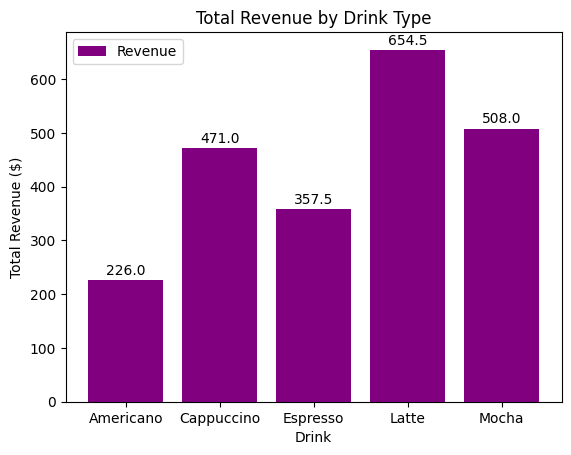

In [145]:
bars = plt.bar(data = revenue_by_drink, x = "Drink", height = "Revenue", color = "purple")
plt.title("Total Revenue by Drink Type")
plt.xlabel("Drink")
plt.ylabel("Total Revenue ($)")
plt.legend(["Revenue"])
for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height}", xy = (bar.get_x() + bar.get_width() / 2, height + 10), ha = "center");

# Line Plot – Revenue Trend Over Days

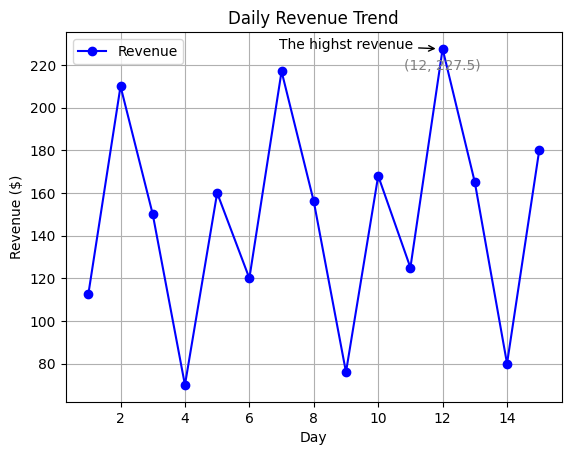

In [144]:
plt.plot("Day", "Revenue", data = data, marker = "o", color = "blue")
plt.title("Daily Revenue Trend")
plt.xlabel("Day")
plt.ylabel("Revenue ($)")
plt.legend(["Revenue"])
plt.grid()
plt.annotate("The highst revenue",
             xy = (12, 227.5),
             xytext = (12 - 3, 227.5),
             ha  = "center",
             arrowprops = {"arrowstyle": "->",
                           "shrinkB": 5
                          }
            )
plt.annotate("(12, 227.5)",
             xy = (12, 227.5),
             xytext = (12, 227.5 - 10),
             ha  = "center",
             color = "grey"
            );
# ملحوظة: الأفضل مع البيانات الكبيرة عندم ادخال احداثيات ال annotation بشكل يدوي

# Scatter Plot – Price vs Units Sold

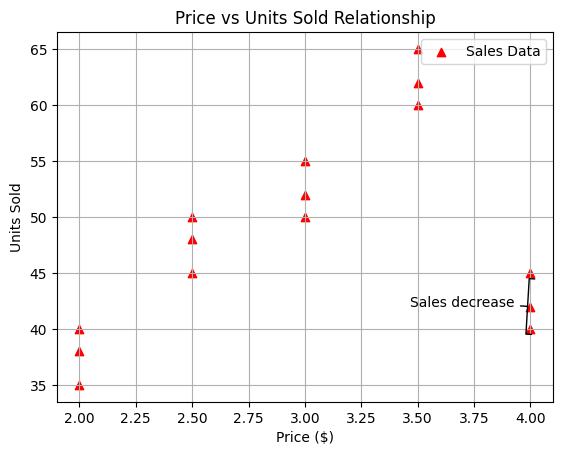

In [143]:
plt.scatter("Price", "Units_Sold", data = data, color = "red", marker = "^")
plt.title("Price vs Units Sold Relationship")
plt.xlabel("Price ($)")
plt.ylabel("Units Sold")
plt.legend(["Sales Data"])
plt.grid()
plt.annotate("Sales decrease",
             xy = (4, 42),
             xytext = (4 - 0.30, 42),
             ha  = "center",
             arrowprops = {"arrowstyle": "-[",
                           "mutation_scale": 20,
                          }
            );

#### There is a positive relation until the price 3.5, then the sales start to decrease 

# Histogram – Distribution of Units Sold

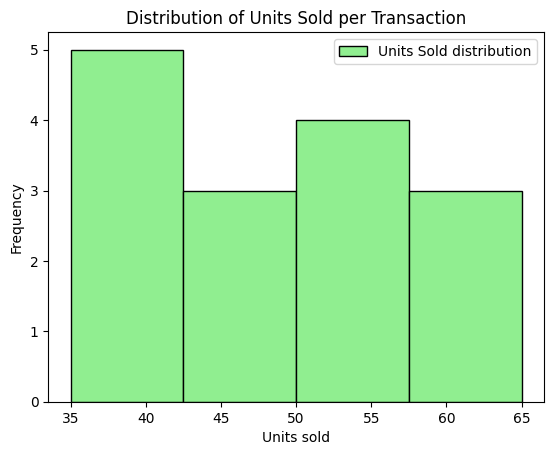

In [146]:
plt.hist("Units_Sold", data = data, bins = 4, edgecolor = "black", color = "lightgreen")
plt.title("Distribution of Units Sold per Transaction")
plt.xlabel("Units sold")
plt.ylabel("Frequency")
plt.legend(["Units Sold distribution"]);

# Multiple Plots (Subplots) – Dashboard

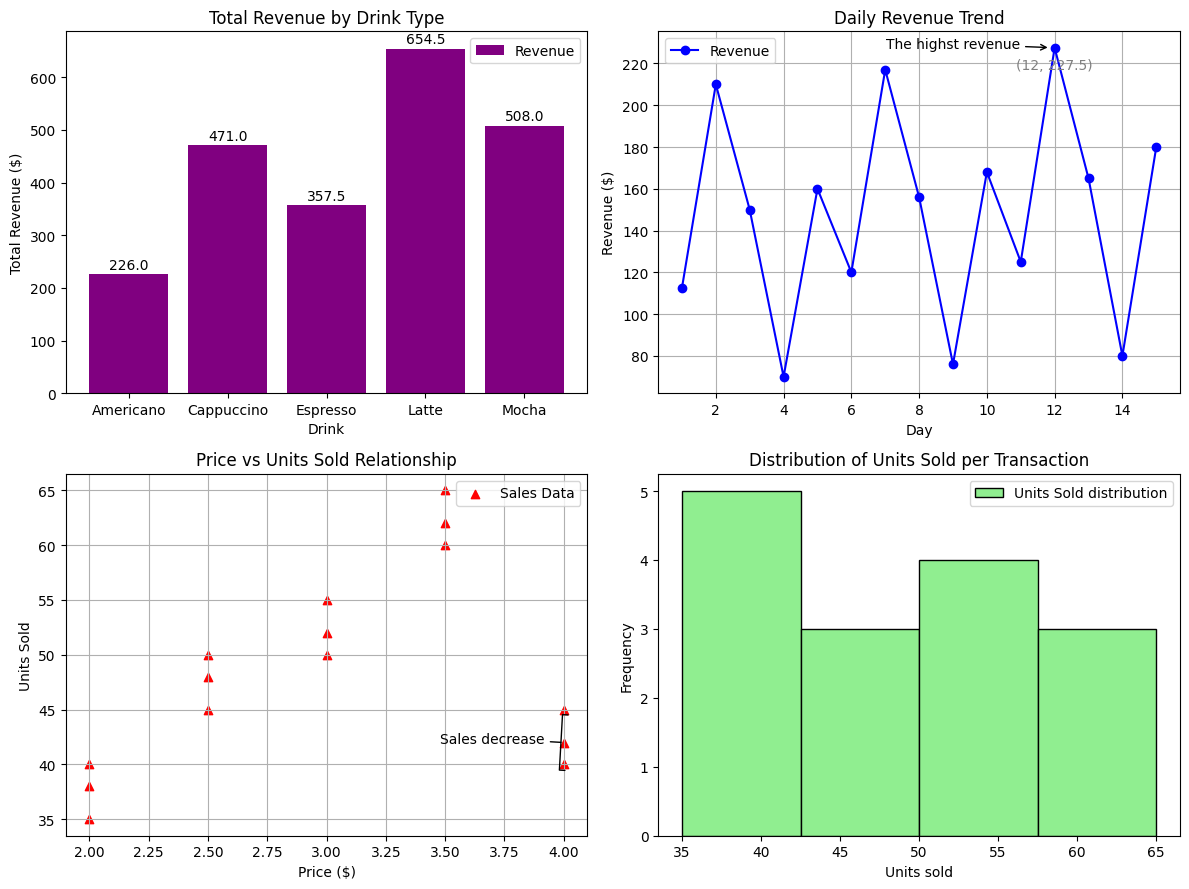

In [169]:
fig, axes = plt.subplots(2, 2, figsize = (12, 9))

# Bar Chart
bars = axes[0, 0].bar(data = revenue_by_drink, x = "Drink", height = "Revenue", color = "purple")
axes[0, 0].set_title("Total Revenue by Drink Type")
axes[0, 0].set_xlabel("Drink")
axes[0, 0].set_ylabel("Total Revenue ($)")
axes[0, 0].legend(["Revenue"])
for bar in bars:
    height = bar.get_height()
    axes[0, 0].annotate(f"{height}", xy = (bar.get_x() + bar.get_width() / 2, height + 10), ha = "center")

# Line PLot
axes[0, 1].plot("Day", "Revenue", data = data, marker = "o", color = "blue")
axes[0, 1].set_title("Daily Revenue Trend")
axes[0, 1].set_xlabel("Day")
axes[0, 1].set_ylabel("Revenue ($)")
axes[0, 1].legend(["Revenue"])
axes[0, 1].grid()
axes[0, 1].annotate("The highst revenue",
             xy = (12, 227.5),
             xytext = (12 - 3, 227.5),
             ha  = "center",
             arrowprops = {"arrowstyle": "->",
                           "shrinkB": 5
                          }
            )
axes[0, 1].annotate("(12, 227.5)",
             xy = (12, 227.5),
             xytext = (12, 227.5 - 10),
             ha  = "center",
             color = "grey"
            )

# Scatter Plot
axes[1, 0].scatter("Price", "Units_Sold", data = data, color = "red", marker = "^")
axes[1, 0].set_title("Price vs Units Sold Relationship")
axes[1, 0].set_xlabel("Price ($)")
axes[1, 0].set_ylabel("Units Sold")
axes[1, 0].legend(["Sales Data"])
axes[1, 0].grid()
axes[1, 0].annotate("Sales decrease",
             xy = (4, 42),
             xytext = (4 - 0.30, 42),
             ha  = "center",
             arrowprops = {"arrowstyle": "-[",
                           "mutation_scale": 20,
                          }
            )

# Histogram
axes[1, 1].hist("Units_Sold", data = data, bins = 4, edgecolor = "black", color = "lightgreen")
axes[1, 1].set_title("Distribution of Units Sold per Transaction")
axes[1, 1].set_xlabel("Units sold")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend(["Units Sold distribution"])

    
plt.tight_layout();

# Saving The Work

In [175]:
fig.savefig("coffee_shop_dashboard.png")